# Basic Operations and Plotting

This tutorial shows basic examples on how to load, handle, and plot the EM-DAT data using the [`dplyr`](https://dplyr.tidyverse.org/) data manipulation package and the [`ggplot2`](https://ggplot2.tidyverse.org/) plotting library, both part of the [tidyverse](https://www.tidyverse.org/).

**Note**: This tutorial is also available on the [EM-DAT Documentation Website](https://doc.emdat.be/docs/additional-resources-and-tutorials/).

## Load Packages

Let us load the necessary packages and print their versions. For this tutorial, we used `readxl` v.1.4.5, `dplyr` v.1.2.0, `tidyr` v.1.3.2, and `ggplot2` v.4.0.2. If your package versions are different, you may have to adapt this tutorial by checking the corresponding package documentation.

In [1]:
# suppressPackageStartupMessages() hides the notes R prints when attaching
# a package; these are informational only, and their language depends on
# your system locale.
suppressPackageStartupMessages({
  library(readxl)   # read Excel files
  library(dplyr)    # data manipulation
  library(tidyr)    # data reshaping
  library(ggplot2)  # plotting library
})

for (p in c("readxl", "dplyr", "tidyr", "ggplot2")) {
  cat(p, as.character(packageVersion(p)), "\n")
}

readxl 1.4.5 
dplyr 1.2.0 
tidyr 1.3.2 
ggplot2 4.0.2 


## Load EM-DAT

To load EM-DAT:

* Download the EM-DAT data at https://public.emdat.be/ (registration is required, see the EM-DAT Documentation page on [Data Accessibility](https://doc.emdat.be/docs/data-accessibility/)). This tutorial uses the [EM-DAT Archive published on Dataverse](https://doi.org/10.14428/DVN/I0LTPH), which covers the years 1900 to 2024;
* Use the [`read_excel`](https://readxl.tidyverse.org/reference/read_excel.html) function to load and parse the data into a `tibble`, R's modern take on the `data.frame`;
* Check if the data has been successfully parsed with the [`glimpse`](https://dplyr.tidyverse.org/reference/glimpse.html) function.

**Notes**:

1. We set `guess_max = 100000` so that `read_excel` scans every row before deciding each column's type. By default it only inspects the first 1000 rows, which would mistype the sparsely populated columns at the end of the table.
2. Another option is to export the `.xlsx` file into a `.csv`, and use the [`read_csv`](https://readr.tidyverse.org/reference/read_delim.html) function from the `readr` package;
3. If not in the same folder as the R script, replace the filename with the relative path or the full path, e.g., `E:/MyDATa/260430_emdat_archive.xlsx`.

In [2]:
df <- read_excel("data/260430_emdat_archive.xlsx", guess_max = 100000)  # <-- modify file name or path
glimpse(df)

Rows: 26,946
Columns: 47
$ DisNo.                                      <chr> "1900-0003-USA", "1900-000…
$ Historic                                    <chr> "Yes", "Yes", "Yes", "Yes"…
$ `Classification Key`                        <chr> "nat-met-sto-tro", "tec-in…
$ `Disaster Group`                            <chr> "Natural", "Technological"…
$ `Disaster Subgroup`                         <chr> "Meteorological", "Industr…
$ `Disaster Type`                             <chr> "Storm", "Fire (Industrial…
$ `Disaster Subtype`                          <chr> "Tropical cyclone", "Fire …
$ `External IDs`                              <chr> NA, NA, NA, NA, NA, NA, NA…
$ `Event Name`                                <chr> NA, NA, NA, "Gastroenterit…
$ ISO                                         <chr> "USA", "USA", "JAM", "JAM"…
$ Country                                     <chr> "United States of America"…
$ Subregion                                   <chr> "Northern America", "North…
$ Region       

## Example 1: Japan Earthquake Data

### Filtering

Let us focus on the EM-DAT earthquakes in Japan from the years 2000 to 2023 and create a suitable filter utilizing the EM-DAT columns `Disaster Type`, `ISO` and `Start Year`.

For simplicity, let's retain only the columns `Start Year`, `Magnitude`, `Total Deaths`, and `Total Affected` and display the first five entries using the [`head`](https://rdrr.io/r/utils/head.html) function.

**Notes**:

1. Column names containing spaces or special characters must be wrapped in backticks in R, e.g., `` `Start Year` ``.
2. We use the native pipe operator `|>` to chain operations, passing the result of one function as the first argument of the next.
3. The archive file covers the years 1900 to 2024, so we set an explicit lower bound on `Start Year`. For further details about the columns, we refer to the EM-DAT Documentation page [EM-DAT Public Table](https://doc.emdat.be/docs/data-structure-and-content/emdat-public-table/).

In [3]:
eq_jpn <- df |>
  filter(
    `Disaster Type` == "Earthquake",
    ISO == "JPN",
    `Start Year` >= 2000,
    `Start Year` < 2024
  ) |>
  select(`Start Year`, Magnitude, `Total Deaths`, `Total Affected`)

head(eq_jpn, 5)

Start Year,Magnitude,Total Deaths,Total Affected
<dbl>,<dbl>,<dbl>,<dbl>
2000,6.1,1,100
2019,6.4,NA,460
2016,7.0,49,298432
2016,6.2,NA,493
2011,9.1,19846,368820


### Grouping

Let us group the data to calculate the number of earthquake events by year and plot the results.

* Use the [`count`](https://dplyr.tidyverse.org/reference/count.html) function to tally the number of rows per group, e.g., per `Start Year`;
* Equivalently, you can combine [`group_by`](https://dplyr.tidyverse.org/reference/group_by.html) with [`summarise`](https://dplyr.tidyverse.org/reference/summarise.html) and the [`n`](https://dplyr.tidyverse.org/reference/context.html) helper;
* Plot the results using [`ggplot`](https://ggplot2.tidyverse.org/reference/ggplot.html) with a [`geom_col`](https://ggplot2.tidyverse.org/reference/geom_bar.html) layer.

**Note**: `n()` counts every row in the group, including those with missing values in other columns. To count only non-missing values in a given column, use `sum(!is.na(x))` instead. Since the field `Start Year` is always defined, both approaches return the same result here.

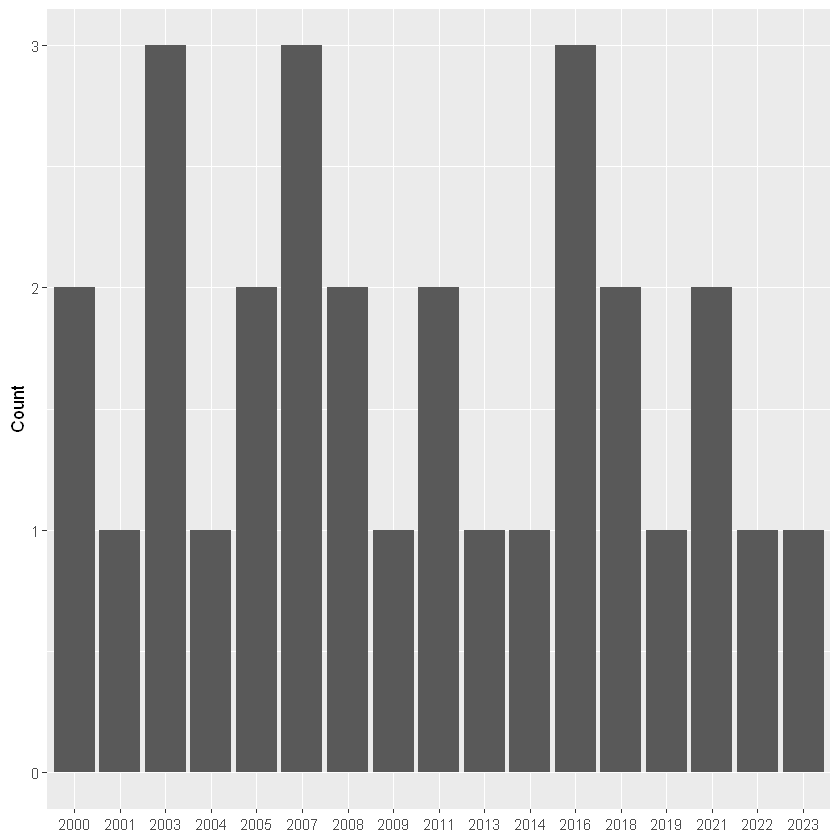

In [4]:
eq_cnt <- eq_jpn |> count(`Start Year`, name = "Count")

ggplot(eq_cnt, aes(x = factor(`Start Year`), y = Count)) +
  geom_col() +
  labs(x = NULL, y = "Count")

### Customize Chart

A `ggplot` is built by adding layers with the `+` operator. To refine the chart, let us add scale and label layers, and adjust the figure size.

**Note**: In a Jupyter notebook, the figure size is controlled with `options(repr.plot.width = ..., repr.plot.height = ...)`, expressed in inches. Outside a notebook, you would set the size when saving with [`ggsave`](https://ggplot2.tidyverse.org/reference/ggsave.html).

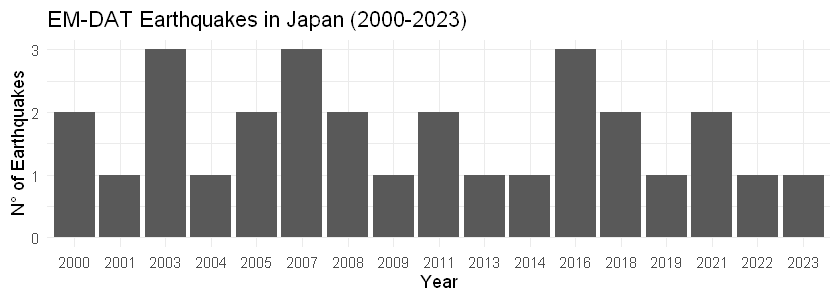

In [5]:
# Set the figure size for this plot
options(repr.plot.width = 7, repr.plot.height = 2.5)

ggplot(eq_cnt, aes(x = factor(`Start Year`), y = Count)) +
  # Draw one bar per year
  geom_col() +
  # Define y-axis tick marks
  scale_y_continuous(breaks = 0:3) +
  # Set axis labels and title
  labs(
    x = "Year",
    y = "N° of Earthquakes",
    title = "EM-DAT Earthquakes in Japan (2000-2023)"
  ) +
  theme_minimal()

## Example 2: Comparing Regions

Let us compare earthquake death toll by continents. As before, we filter the original tibble `df` according to our specific needs, including the `Region` column.

In [6]:
eq_all <- df |>
  filter(
    `Disaster Type` == "Earthquake",
    `Start Year` >= 2000,
    `Start Year` < 2024
  ) |>
  select(`Start Year`, Magnitude, Region, `Total Deaths`, `Total Affected`)

head(eq_all, 5)

Start Year,Magnitude,Region,Total Deaths,Total Affected
<dbl>,<dbl>,<chr>,<dbl>,<dbl>
2000,5.3,Asia,1,2015
2000,4.9,Asia,NA,1000
2000,6.5,Americas,2,430
2000,4.5,Asia,1,1000
2000,6.0,Asia,2,23080


In this case,

* Use [`group_by`](https://dplyr.tidyverse.org/reference/group_by.html) to group based on the `Region` column;
* Use [`summarise`](https://dplyr.tidyverse.org/reference/summarise.html) with `sum` as the aggregation function for the `Total Deaths` field;
* Pass `na.rm = TRUE` to ignore missing values, which otherwise propagate and make the whole sum `NA`.

In [7]:
eq_sum <- eq_all |>
  group_by(Region) |>
  summarise(`Total Deaths` = sum(`Total Deaths`, na.rm = TRUE))

eq_sum

Region,Total Deaths
<chr>,<dbl>
Africa,6312
Americas,229066
Asia,552461
Europe,788
Oceania,641


Finally, let us make a horizontal bar chart of it. In particular,

* map `Total Deaths` to the x axis and `Region` to the y axis to obtain horizontal bars;
* use [`scale_y_discrete`](https://ggplot2.tidyverse.org/reference/scale_discrete.html) with `limits = rev` to display the regions in alphabetical order from top to bottom;
* use [`label_number`](https://scales.r-lib.org/reference/label_number.html) from the `scales` package to express the x axis in thousands of deaths.

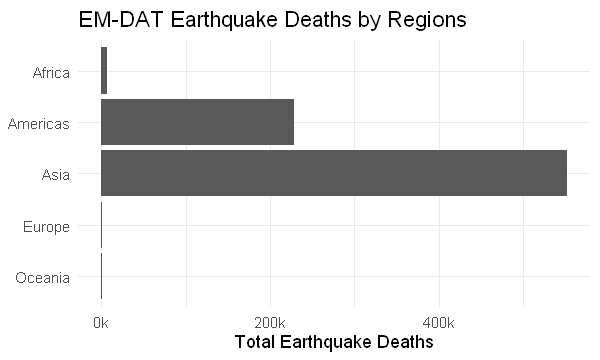

In [8]:
options(repr.plot.width = 5, repr.plot.height = 3)

ggplot(eq_sum, aes(x = `Total Deaths`, y = Region)) +
  geom_col() +
  scale_y_discrete(limits = rev) +
  scale_x_continuous(labels = scales::label_number(scale = 1e-3, suffix = "k")) +
  labs(
    x = "Total Earthquake Deaths",
    y = NULL,
    title = "EM-DAT Earthquake Deaths by Regions"
  ) +
  theme_minimal()

## Example 3: Multiple Grouping

At last, let us report the earthquake time series by continents. We group by both `Region` and `Start Year`, and set `.groups = "drop"` so that the result is returned as a plain, ungrouped tibble ready for further processing.

In [9]:
eq_reg_ts <- eq_all |>
  group_by(Region, `Start Year`) |>
  summarise(`Total Deaths` = sum(`Total Deaths`, na.rm = TRUE), .groups = "drop")

eq_reg_ts

Region,Start Year,Total Deaths
<chr>,<dbl>,<dbl>
Africa,2000,1
Africa,2001,0
Africa,2002,47
Africa,2003,2275
Africa,2004,943
Africa,2005,10
Africa,2006,8
Africa,2008,47
Africa,2009,4


Next, we apply the [`pivot_wider`](https://tidyr.tidyverse.org/reference/pivot_wider.html) function to restructure the table, spreading the regions across columns.

**Note**: Unlike many plotting libraries, `ggplot2` expects *long* data, where each row is one observation and grouping variables live in their own columns. The long `eq_reg_ts` table above is therefore already in the right shape for plotting. We still show the pivot here because the wide layout is convenient for reading the numbers as a table, and for exporting to a spreadsheet.

In [10]:
eq_pivot_ts <- eq_reg_ts |>
  pivot_wider(names_from = Region, values_from = `Total Deaths`)

head(eq_pivot_ts)

Start Year,Africa,Americas,Asia,Europe,Oceania
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2000,1,9,205,0,2
2001,0,1317,20031,0,0
2002,47,0,1554,33,5
2003,2275,38,27300,3,NA
2004,943,10,226336,1,NA
2005,10,17,76213,NA,1


Let us plot the long table as a stacked bar chart, mapping `Region` to the `fill` aesthetic.

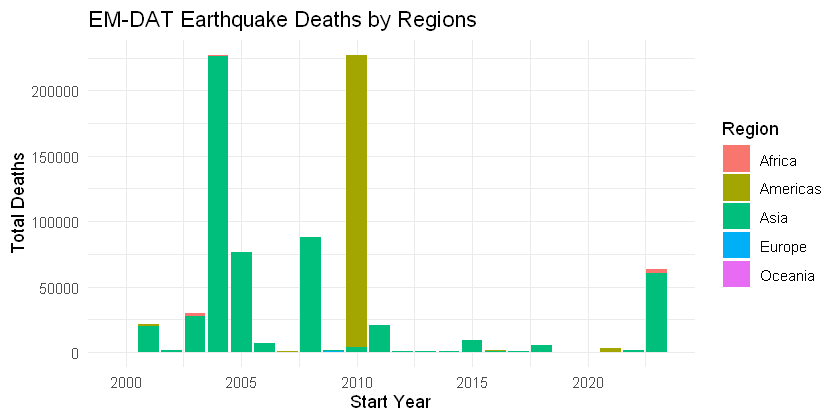

In [11]:
options(repr.plot.width = 7, repr.plot.height = 3.5)

ggplot(eq_reg_ts, aes(x = `Start Year`, y = `Total Deaths`, fill = Region)) +
  geom_col() +
  labs(y = "Total Deaths", title = "EM-DAT Earthquake Deaths by Regions") +
  theme_minimal()

In order to be able to visualize the data in more detail, let us split the chart into one panel per region using [`facet_wrap`](https://ggplot2.tidyverse.org/reference/facet_wrap.html). Setting `scales = "free_y"` lets each panel use its own y axis range.

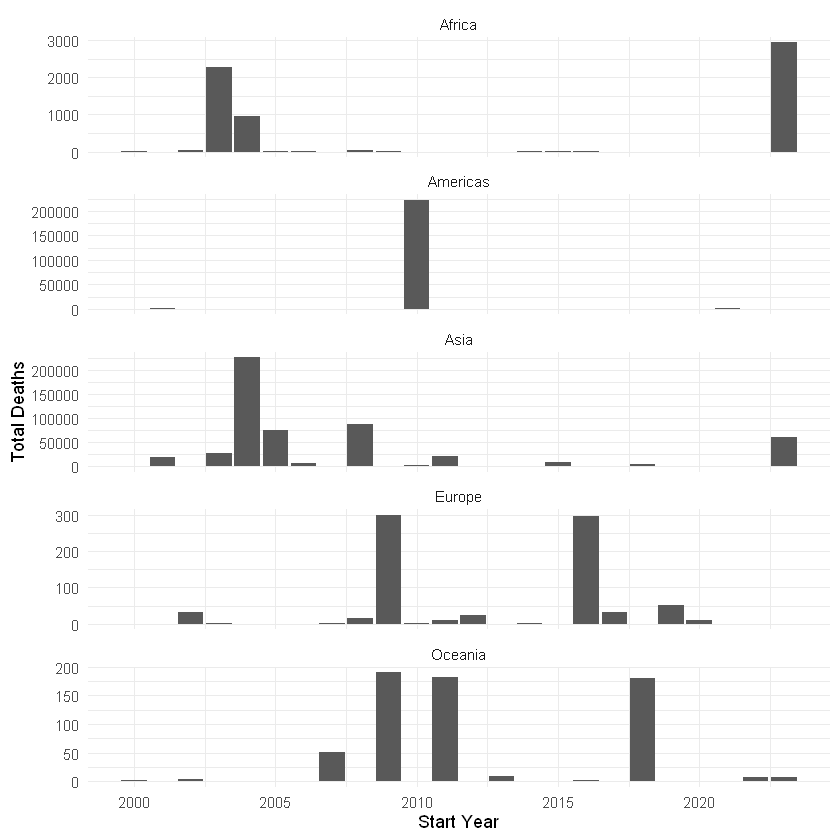

In [12]:
options(repr.plot.width = 7, repr.plot.height = 7)

ggplot(eq_reg_ts, aes(x = `Start Year`, y = `Total Deaths`)) +
  geom_col() +
  facet_wrap(~ Region, ncol = 1, scales = "free_y") +
  labs(y = "Total Deaths") +
  theme_minimal()

We have just covered the most common manipulations applied to a [`dplyr`](https://dplyr.tidyverse.org/) tibble containing the EM-DAT data. To delve further into your analyses, we encourage you to continue your learning of [dplyr](https://dplyr.tidyverse.org/) and [ggplot2](https://ggplot2.tidyverse.org/) with the many resources available online, starting with [R for Data Science](https://r4ds.hadley.nz/).

If you are interested in learning the basics of making maps based on EM-DAT data, you can also follow the [EM-DAT R Tutorial 2: Making Maps](./r_tutorial_2_making_maps.ipynb).